# ISL Hand Sign Keypoint Classifier
This notebook trains a neural network to classify Indian Sign Language (ISL) hand signs (A-Z) using MediaPipe hand landmarks.

In [17]:
import csv
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

## 1. File Paths

In [18]:
#dataset        = 'model/keypoint_classifier/keypoint.csv'
dataset = "model/keypoint_classifier/cleaned.csv" # For both hands
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'

## 2. Class Count

**KEY CHANGE:** Set this to the number of signs you have collected.

- For A-Z (26 letters, single-hand only): `NUM_CLASSES = 26`
- If you also have two-hand signs mixed in: keep the same count but make sure your CSV has the right feature length (see note below).

> **IMPORTANT — Input size note:**
> - Single-hand signs → 21 landmarks × 2 coords = **42 features** per row in the CSV
> - Two-hand signs → 42 landmarks × 2 coords = **84 features** per row in the CSV
>
> You must train **two separate models** if you mix single-hand and two-hand signs, OR pad
> single-hand rows with zeros to always have 84 features and use one model.
> The cell below uses `NUM_FEATURES` so you only have to change it in one place.

In [19]:
NUM_CLASSES = 26          # A-Z = 26. Change if you add more signs later.

# --- Choose ONE of the two options below ---
# Option A: Single-hand only (21 landmarks per hand)
#NUM_FEATURES = 21 * 2     # = 42

# Option B: Two-hand combined (42 landmarks total)
NUM_FEATURES = 42 * 2   # = 84  <-- uncomment this if using two-hand signs

## 3. Load Training Data

In [20]:
# Column 0 = class label, columns 1..NUM_FEATURES = landmark coordinates
X_dataset = np.loadtxt(
    dataset,
    delimiter=',',
    dtype='float32',
    usecols=list(range(1, NUM_FEATURES + 1))
)

y_dataset = np.loadtxt(
    dataset,
    delimiter=',',
    dtype='int32',
    usecols=(0)
)

print(f'Dataset shape: X={X_dataset.shape}, y={y_dataset.shape}')
print(f'Classes found: {sorted(set(y_dataset.tolist()))}')

Dataset shape: X=(163, 84), y=(163,)
Classes found: [0, 1]


In [21]:
# Split: 75% training, 25% validation
X_train, X_test, y_train, y_test = train_test_split(
    X_dataset, y_dataset,
    train_size=0.75,
    random_state=RANDOM_SEED
)
print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

Train: 122 samples | Test: 41 samples


## 4. Build the Model

**KEY CHANGES from original:**
- `Input` layer now uses `NUM_FEATURES` (42 for single-hand, 84 for two-hand)
- Hidden layers are wider (128 → 64) to handle 26 classes instead of 3
- Output layer uses `NUM_CLASSES` (26) instead of hardcoded 3

In [22]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((NUM_FEATURES,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_3 (Dropout)         (None, 84)                0         
                                                                 
 dense_3 (Dense)             (None, 128)               10880     
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dropout_5 (Dropout)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 26)                1690      
                                                                 
Total params: 20,826
Trainable params: 20,826
Non-trai

## 5. Callbacks

In [23]:
# Save best model checkpoint
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path,
    verbose=1,
    save_weights_only=False
)

# Stop early if validation loss stops improving
es_callback = tf.keras.callbacks.EarlyStopping(
    patience=20,
    verbose=1,
    restore_best_weights=True   # <-- added: revert to best epoch on stop
)

## 6. Compile

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 7. Train

In [25]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
1/1 [==============================] - ETA: 0s - loss: 3.7837 - accuracy: 0.0082
Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
1/1 [==============================] - 1s 746ms/step - loss: 3.7837 - accuracy: 0.0082 - val_loss: 3.2330 - val_accuracy: 0.0000e+00
Epoch 2/1000
1/1 [==============================] - ETA: 0s - loss: 3.5304 - accuracy: 0.0000e+00
Epoch 2: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
1/1 [==============================] - 0s 226ms/step - loss: 3.5304 - accuracy: 0.0000e+00 - val_loss: 3.0378 - val_accuracy: 0.0000e+00
Epoch 3/1000
1/1 [==============================] - ETA: 0s - loss: 3.2758 - accuracy: 0.0328
Epoch 3: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
1/1 [==============================] - 0s 359ms/step - loss: 3.2758 - accuracy: 0.0328 - val_loss: 2.8778 - val_accuracy: 0.0000e+00
Epoch 4/1000
1/1 [==============================] - ETA: 0s - loss: 3.1056 - accura

## 8. Evaluate

In [26]:
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)
print(f'Validation loss: {val_loss:.4f} | Validation accuracy: {val_acc:.4f}')

1/1 [==============================] - 0s 24ms/step - loss: 0.0564 - accuracy: 1.0000
Validation loss: 0.0564 | Validation accuracy: 1.0000


## 9. Reload Saved Model & Quick Inference Test

In [27]:
# Load the best saved model
model = tf.keras.models.load_model(model_save_path)

# Run inference on one test sample
predict_result = model.predict(np.array([X_test[0]]))
print('Class probabilities:', np.squeeze(predict_result))
print('Predicted class index:', np.argmax(np.squeeze(predict_result)))
print('True class index:     ', y_test[0])

1/1 [==============================] - 0s 50ms/step
Class probabilities: [1.27962385e-05 9.99970436e-01 4.92591390e-08 1.69313864e-07
 1.58055400e-07 2.52474610e-08 6.78582751e-07 7.06509624e-08
 2.17863430e-07 5.75955639e-09 7.46823389e-07 1.58923346e-08
 1.53720563e-07 2.74664728e-07 3.69501379e-07 1.04377423e-05
 4.65851400e-07 2.11865668e-07 9.37915630e-08 5.02485420e-07
 2.02249737e-08 4.61222349e-08 3.75118674e-07 5.04724156e-08
 1.29611337e-07 1.62653794e-06]
Predicted class index: 1
True class index:      1


## 10. Confusion Matrix & Classification Report

2/2 [==============================] - 0s 9ms/step


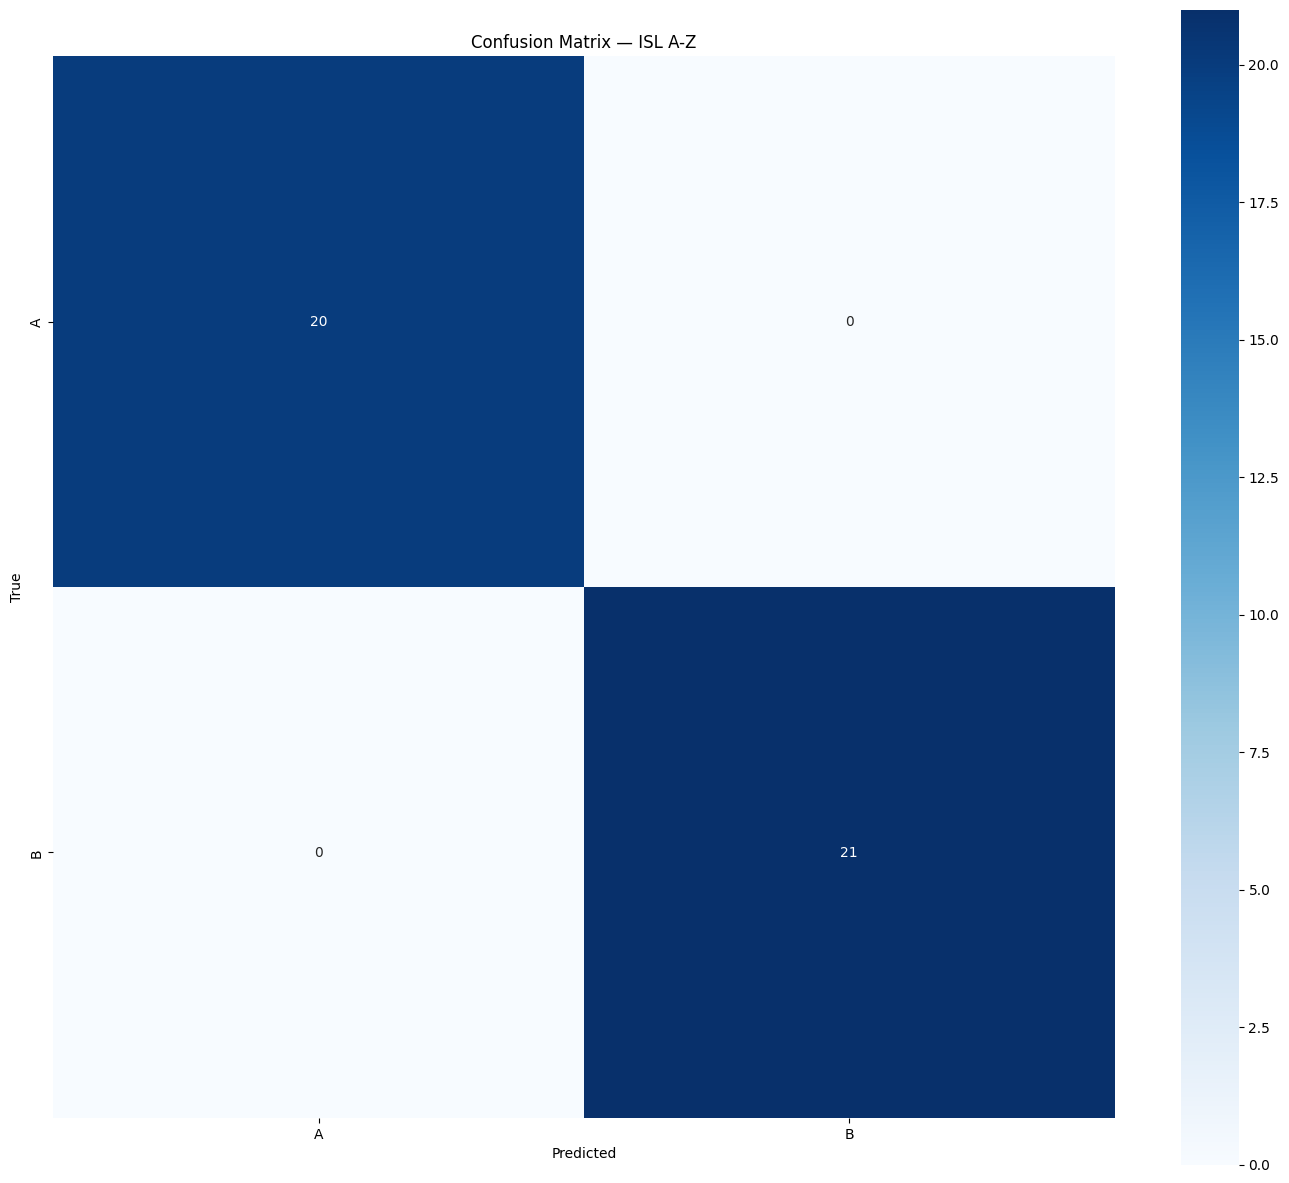

Classification Report
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        20
           B       1.00      1.00      1.00        21

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41



In [28]:
import string
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Map class indices 0-25 to letters A-Z for readable labels
ALPHABET = list(string.ascii_uppercase)  # ['A', 'B', ..., 'Z']

def print_confusion_matrix(y_true, y_pred, class_names, report=True):
    labels = sorted(list(set(y_true)))
    label_names = [class_names[i] for i in labels]

    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    df_cmx = pd.DataFrame(cmx_data, index=label_names, columns=label_names)

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(df_cmx, annot=True, fmt='g', square=True, cmap='Blues')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Confusion Matrix — ISL A-Z')
    plt.tight_layout()
    plt.show()

    if report:
        print('Classification Report')
        print(classification_report(y_true, y_pred, target_names=label_names))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred, class_names=ALPHABET)

## 11. Convert to TensorFlow Lite (for use in app.py)

In [29]:
# Save inference-only model (no optimizer state)
model.save(model_save_path, include_optimizer=False)

In [30]:
# Convert to quantized TFLite model (smaller & faster on CPU/edge devices)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)
print(f'TFLite model saved to: {tflite_save_path}')

INFO:tensorflow:Assets written to: C:\Users\admin\AppData\Local\Temp\tmprib0a_c_\assets


INFO:tensorflow:Assets written to: C:\Users\admin\AppData\Local\Temp\tmprib0a_c_\assets


TFLite model saved to: model/keypoint_classifier/keypoint_classifier.tflite


## 12. TFLite Inference Test

In [31]:
# Load TFLite model and allocate tensors
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

# Get input/output tensor info
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('Input shape expected by TFLite model:', input_details[0]['shape'])
# Should print: [1, 42] for single-hand or [1, 84] for two-hand

Input shape expected by TFLite model: [ 1 84]


In [32]:
%%time
# Run TFLite inference on one test sample
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

print('TFLite class probabilities:', np.squeeze(tflite_results))
print('TFLite predicted class:    ', np.argmax(np.squeeze(tflite_results)))
print('Keras  predicted class:    ', np.argmax(model.predict(np.array([X_test[0]]))))
print('True class:                ', y_test[0])

TFLite class probabilities: [1.2936073e-05 9.9997008e-01 5.0361997e-08 1.7353092e-07 1.6150798e-07
 2.6216016e-08 6.8686757e-07 7.4107099e-08 2.2415614e-07 5.9531478e-09
 7.5547001e-07 1.6446387e-08 1.5863628e-07 2.8381044e-07 3.7421205e-07
 1.0441561e-05 4.6775483e-07 2.2047392e-07 9.6466934e-08 5.1236060e-07
 2.1008304e-08 4.6835677e-08 3.8157160e-07 5.1115485e-08 1.3441679e-07
 1.6545956e-06]
TFLite predicted class:     1
1/1 [==============================] - 0s 20ms/step
Keras  predicted class:     1
True class:                 1
CPU times: total: 62.5 ms
Wall time: 66.8 ms
